In [677]:
# import libraries
import pandas as pd
import numpy as np
!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.stats import t 
from sklearn.decomposition import PCA
from scipy.stats.contingency import association


Nam Nguyen
Student ID: 012082998


In [679]:
#Importing Data
filename = 'churn_clean.csv'
df = pd.read_csv(filename, na_values = ['null','N/A',' ', '', '.','nan']) 

In [680]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [681]:
df.describe()


,CaseOrder,Zip,Lat,Lng,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,49153.319600,38.757567,-90.782536,9756.562400,2.0877,53.078400,39806.926771,10.001848,12.016000,0.994200,0.398000,34.526188,172.624816,3392.341550,3.490800,3.505100,3.487000,3.497500,3.492900,3.497300,3.509500,3.495600
std,2886.89568,27532.196108,5.437389,15.156142,14432.698671,2.1472,20.698882,28199.916702,2.976019,3.025898,0.988466,0.635953,26.443063,42.943094,2185.294852,1.037797,1.034641,1.027977,1.025816,1.024819,1.033586,1.028502,1.028633
min,1.00000,601.000000,17.966120,-171.688150,0.000000,0.0000,18.000000,348.670000,0.099747,1.000000,0.000000,0.000000,1.000259,79.978860,155.506715,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,26292.500000,35.341828,-97.082812,738.000000,0.0000,35.000000,19224.717500,8.018214,10.000000,0.000000,0.000000,7.917694,139.979239,1236.470827,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,48869.500000,39.395800,-87.918800,2910.500000,1.0000,53.000000,33170.605000,10.018560,12.000000,1.000000,0.000000,35.430507,167.484700,3279.536903,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,7500.25000,71866.500000,42.106908,-80.088745,13168.000000,3.0000,71.000000,53246.170000,11.969485,14.000000,2.000000,1.000000,61.479795,200.734725,5586.141370,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,99929.000000,70.640660,-65.667850,111850.000000,10.0000,89.000000,258900.700000,21.207230,23.000000,7.000000,6.000000,71.999280,290.160419,7158.981530,7.000000,7.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000


In [682]:
pd.set_option('display.max_columns', None)

print(df.head())

   CaseOrder Customer_id                           Interaction  \
0          1     K409198  aa90260b-4141-4a24-8e36-b04ce1f4f77b   
1          2     S120509  fb76459f-c047-4a9d-8af9-e0f7d4ac2524   
2          3     K191035  344d114c-3736-4be5-98f7-c72c281e2d35   
3          4      D90850  abfa2b40-2d43-4994-b15a-989b8c79e311   
4          5     K662701  68a861fd-0d20-4e51-a587-8a90407ee574   

                                UID         City State                 County  \
0  e885b299883d4f9fb18e39c75155d990  Point Baker    AK  Prince of Wales-Hyder   
1  f2de8bef964785f41a2959829830fb8a  West Branch    MI                 Ogemaw   
2  f1784cfa9f6d92ae816197eb175d3c71      Yamhill    OR                Yamhill   
3  dc8a365077241bb5cd5ccd305136b05e      Del Mar    CA              San Diego   
4  aabb64a116e83fdc4befc1fbab1663f9    Needville    TX              Fort Bend   

     Zip       Lat        Lng  Population      Area             TimeZone  \
0  99927  56.25100 -133.37571          3

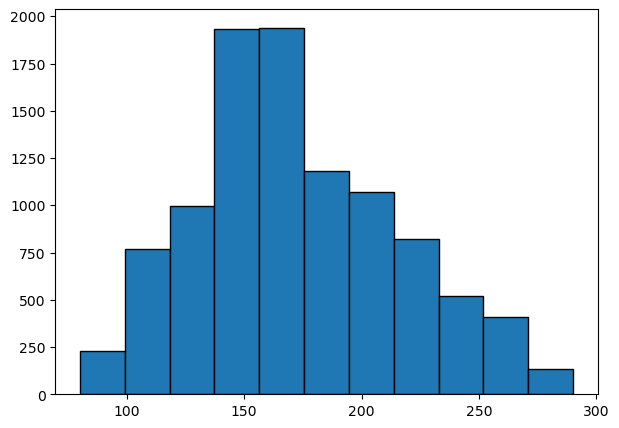

In [683]:
plt.figure(figsize = (7,5))
plt.hist(df['MonthlyCharge'], bins = 11, edgecolor = 'black')
plt.show()

Null Hypothesis: There is no meaningful difference in the monthly charges between churners and non churners

Alt Hypothesis: Churners pay more than non-churners. 

this will be a right tailed test




In [685]:
#We need the mean, standard deviation, and number of observations for each group in order to fill in the formula for the Two sample T test

xbar = df.groupby('Churn')['MonthlyCharge'].mean()
print("means :", xbar)

s= df.groupby('Churn')['MonthlyCharge'].std()
print('standard deviation : ', s)

n = df.groupby('Churn')['MonthlyCharge'].count()
print('count of values : ', n)

varxy =df.groupby('Churn')['MonthlyCharge'].var()

print('Variance :', varxy)

print('Variance ratio' ,1546/1703 , 1703/1546)

means : Churn
No     163.008973
Yes    199.295175
Name: MonthlyCharge, dtype: float64
standard deviation :  Churn
No     39.322148
Yes    41.268191
Name: MonthlyCharge, dtype: float64
count of values :  Churn
No     7350
Yes    2650
Name: MonthlyCharge, dtype: int64
Variance : Churn
No     1546.231296
Yes    1703.063567
Name: MonthlyCharge, dtype: float64
Variance ratio 0.907809747504404 1.1015523932729625


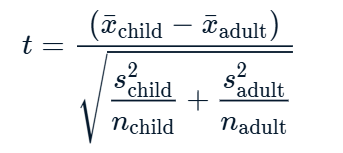

In [687]:
#Assigning values to the variables in order to plug into the formula

#means of the group
xYes = 199.295175
xNo = 163.008973

#Standard deviation
sYes = 41.268191
sNo = 39.322148

#number of variables 
nYes = 2650
nNo = 7350

numerator = xYes - xNo

denominator = np.sqrt(sYes**2/nYes + sNo **2/ nNo)

t_stat = numerator / denominator

print(t_stat)



39.28778554725533


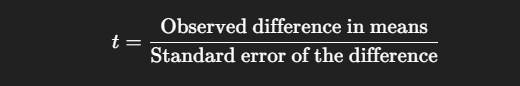


In [689]:
#observed difference between churners and non churners in monthlycharge as a T statistic is $39.28

#Calculating degrees of freedom
dofd = nYes + nNo - 2

print(dofd)



9998


In [690]:
#Calculating P values

pvalue = 1- t.cdf(t_stat, df = dofd)
print(pvalue)


0.0


My significance level is 5 percent
P value is extremely low that we must reject null hypothesis




C.  In a document file, identify the distribution of two continuous variables and two categorical variables using univariate statistics from your cleaned and prepared data.

1.  Represent your findings in part C visually as part of your submission.n.

In [693]:
#Bandwidth_GB_Year as a univariate graph 
print(df['Bandwidth_GB_Year'].describe())

bwgy = df['Bandwidth_GB_Year']
bwgy_range = bwgy.max() - bwgy.min()
print("range",bwgy_range)


count    10000.000000
mean      3392.341550
std       2185.294852
min        155.506715
25%       1236.470827
50%       3279.536903
75%       5586.141370
max       7158.981530
Name: Bandwidth_GB_Year, dtype: float64
range 7003.4748152


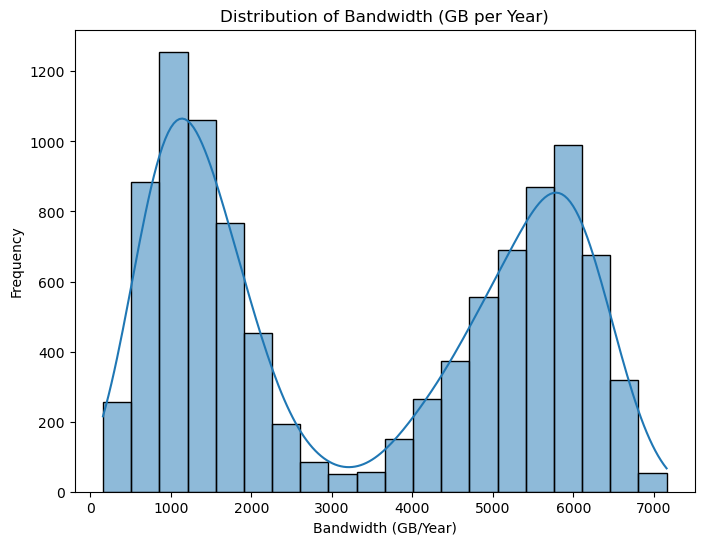

In [694]:
plt.figure(figsize=(8,6))
sns.histplot(df['Bandwidth_GB_Year'], bins=20, kde = True)
plt.title("Distribution of Bandwidth (GB per Year)")
plt.xlabel("Bandwidth (GB/Year)")
plt.ylabel("Frequency")
plt.show()

In [695]:
print(df['Income'].describe())

df_inc = df['Income']
inc_range = df_inc.max() - df_inc.min()
print("range",inc_range)

count     10000.000000
mean      39806.926771
std       28199.916702
min         348.670000
25%       19224.717500
50%       33170.605000
75%       53246.170000
max      258900.700000
Name: Income, dtype: float64
range 258552.03


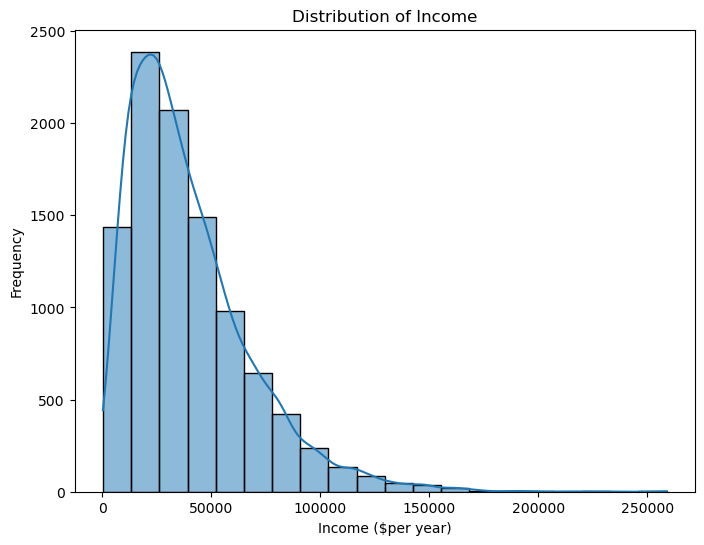

In [696]:
#Graph for "Income" variable

plt.figure(figsize=(8,6))
sns.histplot(df['Income'], bins=20, kde=True)
plt.title("Distribution of Income")
plt.xlabel("Income ($per year)")
plt.ylabel("Frequency")
plt.show()

In [697]:
print(df['Contract'].count())
df['Contract'].value_counts(normalize=True).mul(100).round(2)


10000


Contract
Month-to-month    54.56
Two Year          24.42
One year          21.02
Name: proportion, dtype: float64

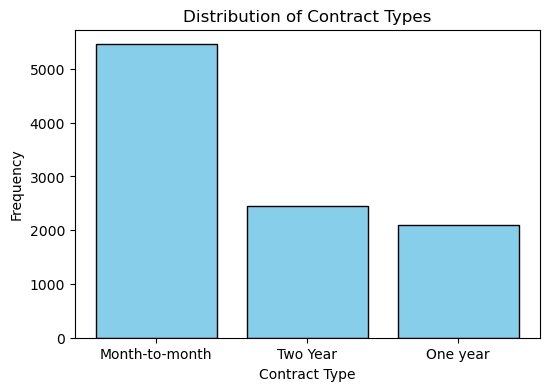

In [698]:
#Graph for "Contract"
contract_counts = df['Contract'].value_counts() #gets the amount of counts for each value 
plt.figure(figsize=(6,4))
plt.bar(contract_counts.index, contract_counts.values, color="skyblue", edgecolor="black") #index gets labels, values gives counts. 
plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Frequency")
plt.show()

In [699]:
#percentages for values of "Churn"
print(df['Churn'].count())
df['Churn'].value_counts(normalize=True).mul(100).round(2)


10000


Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

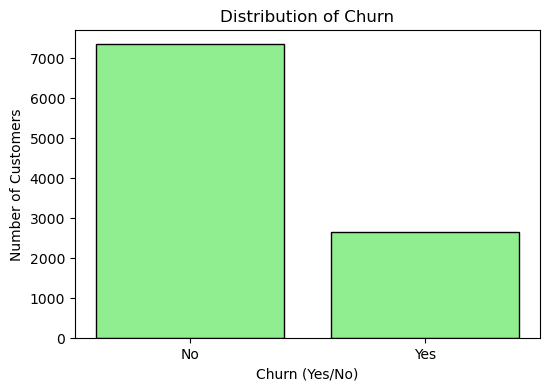

Churn
No     7350
Yes    2650
Name: count, dtype: int64


In [700]:
#Making barplot for "Churn"

churn_counts = df['Churn'].value_counts()
plt.figure(figsize = (6,4))
plt.bar(churn_counts.index, churn_counts.values, color = 'lightgreen',edgecolor = 'black')
plt.title('Distribution of Churn')
plt.xlabel('Churn (Yes/No)')
plt.ylabel("Number of Customers")
plt.show()
print(churn_counts)

D.  In a document file, identify the distribution of two continuous variables and two categorical variables using bivariate statistics from your cleaned and prepared data.

1.  Represent your findings in part D visually as part of your submission.


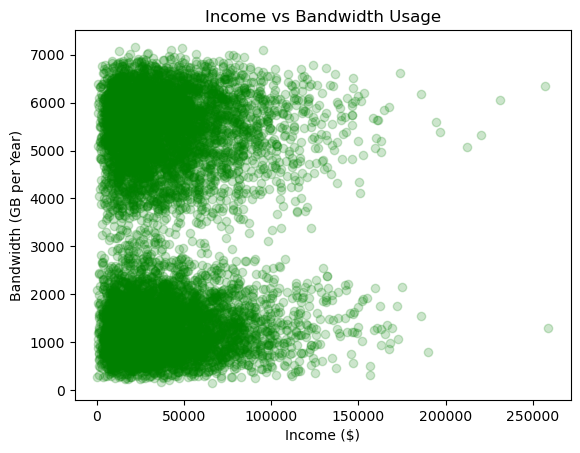

In [702]:
#Continous Variable bivariate graphs
#Income + Bandwidth_gb_year
plt.scatter(df['Income'], df['Bandwidth_GB_Year'], alpha=0.2, color='green')
plt.title("Income vs Bandwidth Usage")
plt.xlabel("Income ($)")
plt.ylabel("Bandwidth (GB per Year)")
plt.show()

In [703]:
#Correlation between the two continous variables "Income" and "Bandwidth_GB_Year"
r = df['Income'].corr(df['Bandwidth_GB_Year'], method='pearson')
print(r)




0.003673549628484681


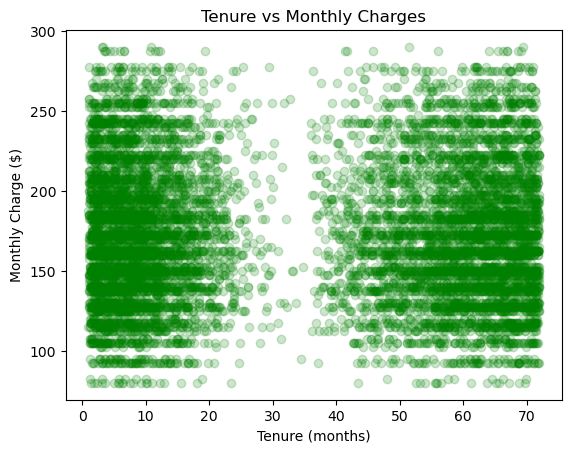

In [704]:
#Continous variable bivariate graphs
#Tenure + MonthlyCharge 

plt.scatter(df['Tenure'], df['MonthlyCharge'], alpha=0.2, color='green')
plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charge ($)")
plt.show()

In [705]:
#Correlation between the two continous variables "Tenure" and "MonthlyCharge"
r = df['Tenure'].corr(df['MonthlyCharge'], method='pearson')
print(r)




-0.0033368104134518864


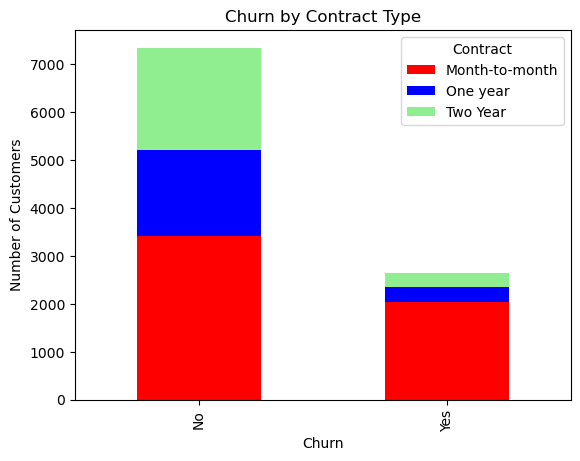

In [706]:
#Categorical: Crosstab with Contract and Churn
pd.crosstab(df['Churn'], df['Contract']).plot(kind='bar', stacked=True, color=['red','blue','lightgreen'])
plt.title("Churn by Contract Type")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [707]:
#Cramers V association test for two categoricals 

table = pd.crosstab(df['Churn'], df['Contract'])
cramers_v = association(table, method="cramer")
print("Cramér's V:", cramers_v)


Cramér's V: 0.26806558536950914


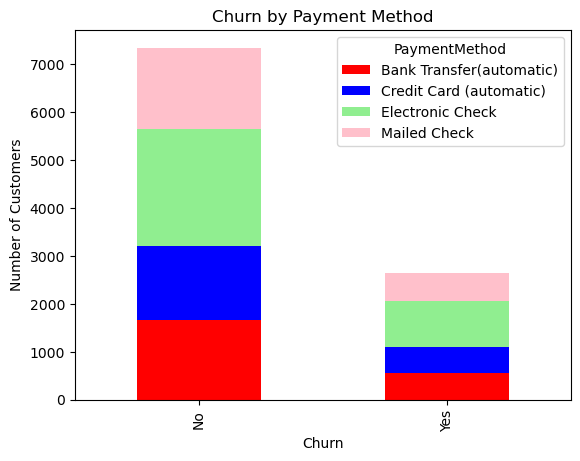

In [708]:
#Categorical: Crosstab with Churn and PaymentMethod
pd.crosstab(df['Churn'], df['PaymentMethod']).plot(kind='bar', stacked=True, color=['red','blue','lightgreen','pink'])
plt.title("Churn by Payment Method")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()